In [1]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","")
sys.path.append(currentPath)

In [2]:
import pandas as pd

In [3]:
import seaborn as sns


In [4]:
df = pd.read_csv(r"d:/Downloads/decision_tree_result.csv")
df


,phone_no,avg_pay,label,features,classweightcol,rawprediction,probability,prediction
0,2000121,53.333333,1,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.980747,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
1,2000415,62.333333,0,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.019253,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
2,2001102,62.333333,1,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.980747,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
3,2001176,23.333333,0,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.019253,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
4,2001498,62.333333,1,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.980747,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
...,...,...,...,...,...,...,...,...
6072,5400624,62.333333,0,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.019253,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
6073,5400876,62.333333,0,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.019253,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
6074,5400959,35.500000,0,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.019253,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0
6075,5401123,62.333333,0,"{""type"":1,""size"":null,""indices"":null,""values"":...",0.019253,"{""type"":1,""size"":null,""indices"":null,""values"":...","{""type"":1,""size"":null,""indices"":null,""values"":...",0


In [5]:

from sklearn.metrics import confusion_matrix

confusion_matrix(
    df["label"],   # array, Gound true (correct) target values
    df["prediction"],  # array, Estimated targets as returned by a classifier
    labels=None,  # array, List of labels to index the matrix.
    sample_weight=None  # array-like of shape = [n_samples], Optional sample weights
)

array([[4167, 1793],
       [  51,   66]], dtype=int64)

[[4167 1793]
 [  51   66]]
[4167 1793   51   66]


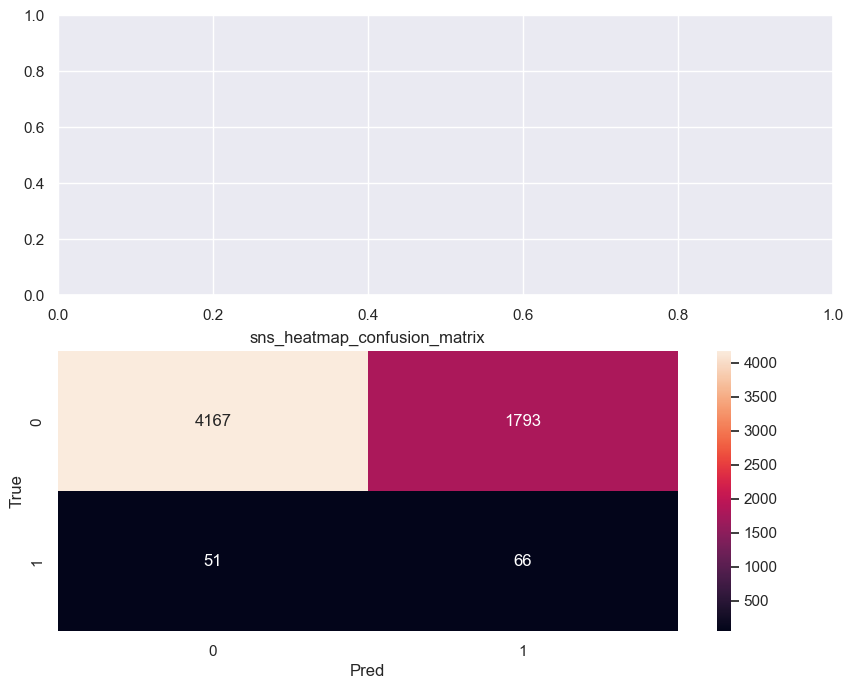

In [6]:
import matplotlib.pyplot as plt
sns.set()

f, (ax1,ax2) = plt.subplots(figsize = (10, 8),nrows=2)
y_true = df["label"]
y_pred = df["prediction"]
C2= confusion_matrix(y_true, y_pred)
print(C2)
print(C2.ravel())
sns.heatmap(C2,annot=True,fmt='d')

ax2.set_title('sns_heatmap_confusion_matrix')
ax2.set_xlabel('Pred')
ax2.set_ylabel('True')
f.savefig('sns_heatmap_confusion_matrix.jpg', bbox_inches='tight')

In [7]:
pred = df["prediction"]
pred

0       0
1       0
2       0
3       0
4       0
       ..
6072    0
6073    0
6074    0
6075    0
6076    0
Name: prediction, Length: 6077, dtype: int64

In [8]:
pred.value_counts()

0    4218
1    1859
Name: prediction, dtype: int64

In [9]:
def func(x:str):
    print(x)
    if x != "null":
        x = x.replace("null","None")
        return eval(x)

In [10]:
value = df["features"].apply(func).apply(lambda x:x["values"][0])
value

{"type":1,"size":null,"indices":null,"values":[53.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[23.333333333333332]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[72.33333333333333]}
{"type":1,"size":null,"indices":null,"values":[70.49666666666667]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[59.0]}
{"type":1,"size":null,"indices":null,"values":[110.66666666666667]}
{"type":1,"size":null,"indices":null,"values":[112.33]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[53.333333333333336]}
{"type":1,"size":null,"indices":null,"values":[62.333333333333336]}
{"type":

0       53.333333
1       62.333333
2       62.333333
3       23.333333
4       62.333333
          ...    
6072    62.333333
6073    62.333333
6074    35.500000
6075    62.333333
6076    62.333333
Name: features, Length: 6077, dtype: float64

<AxesSubplot:xlabel='features'>

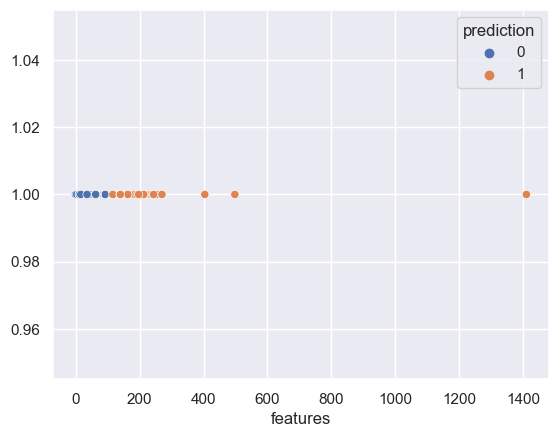

In [11]:
sns.scatterplot(x = value,y = 1,hue=pred)